# Michelson-Morley: Derived Exactly as in the Feynman Lectures (§15-3)

Following [Feynman I, Ch. 15, §15-3](https://www.feynmanlectures.caltech.edu/I_15.html#Ch15-S3)
step by step, same notation: mirrors $B$ (parallel to the aether wind, at
distance $L$) and $C$ (perpendicular, also at distance $L$) reflect light
from a half-silvered mirror $A$ back to detector $E$; the apparatus moves
at speed $u$ through the hypothesized aether. This notebook reproduces
Feynman's EXACT algebra (equations 15.4-15.7, his own symbols $t_1,t_2,
t_3$), verified with SymPy at each step rather than copied, then continues
into the predicted vs. observed fringe shift, why special relativity
predicts an EXACT null result, and what it actually takes to FABRICATE
mirrors and a beamsplitter precise enough for this experiment to mean
anything. Engine: `dgs/michelson_morley.py`.


In [1]:
%matplotlib inline
import sys, pathlib
sys.path.insert(0, str(pathlib.Path('..').resolve()))

import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

from dgs import michelson_morley as mm
from dgs import photodetector_tia_frontend as tia

sp.init_printing(use_latex='mathjax')
print('Setup complete.')


Setup complete.


## 1. Theory: Feynman's Exact Derivation (§15-3, Eq. 15.4-15.5)

**Leg $A\to B$ (downstream)**: in time $t_1$ light travels distance $L$
plus however far $B$ itself has drifted, $ut_1$ (the aether wind carries
the whole apparatus along):
$$ct_1=L+ut_1\quad\text{or}\quad t_1=\frac{L}{c-u}.$$

**Leg $B\to A$ (upstream, returning)**: in time $t_2$, mirror $A$ has
drifted TOWARD the returning light by $ut_2$, shortening the distance:
$$ct_2=L-ut_2\quad\text{or}\quad t_2=\frac{L}{c+u}.$$

**Sum** (Feynman's Eq. 15.4):
$$t_1+t_2=\frac{2Lc}{c^2-u^2}=\frac{2L/c}{1-u^2/c^2}.$$

**Leg $A\to C$ (transverse)**: over time $t_3$ the apparatus drifts $ut_3$
sideways, so light's actual path (in the aether frame) is the hypotenuse
$BC'$ of a right triangle with legs $L$ and $ut_3$:
$$(ct_3)^2=L^2+(ut_3)^2\ \Rightarrow\ L^2=(c^2-u^2)t_3^2\ \Rightarrow\
t_3=\frac{L}{\sqrt{c^2-u^2}}.$$

**Round trip** (Feynman's Eq. 15.5):
$$2t_3=\frac{2L}{\sqrt{c^2-u^2}}=\frac{2L/c}{\sqrt{1-u^2/c^2}}.$$

Every step solved symbolically below, in Feynman's own variable names --
then cross-checked against `dgs.michelson_morley`'s
`longitudinal_time`/`transverse_time` (which use $v$ for $u$, $t_\parallel$
for $t_1+t_2$, $t_\perp$ for $2t_3$ -- same physics, this repo's naming).


In [2]:
L, u, c, t1, t2, t3 = sp.symbols('L u c t_1 t_2 t_3', positive=True)

# leg A->B (downstream): ct_1 = L + u*t_1
t1_solved = sp.solve(sp.Eq(c*t1, L + u*t1), t1)[0]
print('t_1 (A->B, downstream) =', t1_solved)

# leg B->A (upstream): ct_2 = L - u*t_2
t2_solved = sp.solve(sp.Eq(c*t2, L - u*t2), t2)[0]
print('t_2 (B->A, upstream)   =', t2_solved)

# combine over a common denominator -- Feynman's intermediate step
# t_1+t_2 = 2Lc/(c^2-u^2) -- BEFORE dividing num/denom by c^2
sum_t1_t2_raw = sp.together(t1_solved + t2_solved)
print('\nt_1 + t_2             =', sum_t1_t2_raw)

# Eq. 15.4 exactly as printed: divide numerator and denominator by c^2
sum_t1_t2 = (2*L/c) / (1 - u**2/c**2)
same_as_raw = sp.simplify(sum_t1_t2 - sum_t1_t2_raw) == 0
print('t_1 + t_2 (Eq. 15.4)   =', sum_t1_t2, '  (== the raw form above:', same_as_raw, ')')


t_1 (A->B, downstream) = L/(c - u)
t_2 (B->A, upstream)   = L/(c + u)

t_1 + t_2             = 2*L*c/((c - u)*(c + u))
t_1 + t_2 (Eq. 15.4)   = 2*L/(c*(1 - u**2/c**2))   (== the raw form above: True )


In [3]:
# leg A->C (transverse): (c*t_3)^2 = L^2 + (u*t_3)^2
eq_t3 = sp.Eq((c*t3)**2, L**2 + (u*t3)**2)
print('(c*t_3)^2 = L^2 + (u*t_3)^2  i.e.', eq_t3)

# Feynman's exact next step: move the u^2*t_3^2 term over and factor --
# L^2 = c^2*t_3^2 - u^2*t_3^2 = (c^2-u^2)*t_3^2
rearranged = sp.Eq(L**2, c**2*t3**2 - u**2*t3**2)
factored = sp.Eq(L**2, (c**2 - u**2)*t3**2)
print(rearranged, '  =>  ', factored)

# t_3 = L/sqrt(c^2-u^2) -- the clean closed form printed in the book
t3_solved = sp.powsimp(sp.sqrt(L**2/(c**2 - u**2)), force=True)
print('\nt_3 (A->C, transverse) =', t3_solved)

# confirm this is the same (positive) root sp.solve finds on its own
candidates = sp.solve(eq_t3, t3)
sample = {L: 1.0, u: 0.1, c: 1.0}
positive_root = [cand for cand in candidates if float(cand.subs(sample)) > 0][0]
matches_solve = abs(float((t3_solved - positive_root).subs({L: 3.0, u: 0.4, c: 1.0}))) < 1e-12
print(f'matches sp.solve\'s positive root: {matches_solve}')

two_t3 = 2*t3_solved
print('\n2*t_3 (Eq. 15.5)       =', two_t3)


(c*t_3)^2 = L^2 + (u*t_3)^2  i.e. Eq(c**2*t_3**2, L**2 + t_3**2*u**2)
Eq(L**2, c**2*t_3**2 - t_3**2*u**2)   =>   Eq(L**2, t_3**2*(c**2 - u**2))

t_3 (A->C, transverse) = L*sqrt(1/(c**2 - u**2))
matches sp.solve's positive root: True

2*t_3 (Eq. 15.5)       = 2*L*sqrt(1/(c**2 - u**2))


In [4]:
# numerically cross-check Feynman's exact formulas against this repo's module
L_val, u_val = 11.0, 3.0e4
t1_t2_numeric = float(sum_t1_t2.subs({L: L_val, u: u_val, c: mm.C}))
two_t3_numeric = float(two_t3.subs({L: L_val, u: u_val, c: mm.C}))
t_par_module = mm.longitudinal_time(L_val, u_val)
t_perp_module = mm.transverse_time(L_val, u_val)

print(f"Feynman's t_1+t_2:  {t1_t2_numeric:.9e} s   dgs.longitudinal_time: {t_par_module:.9e} s   "
      f"match: {abs(t1_t2_numeric-t_par_module)<1e-20}")
print(f"Feynman's 2*t_3:    {two_t3_numeric:.9e} s   dgs.transverse_time:   {t_perp_module:.9e} s   "
      f"match: {abs(two_t3_numeric-t_perp_module)<1e-20}")


Feynman's t_1+t_2:  7.338410168e-08 s   dgs.longitudinal_time: 7.338410168e-08 s   match: True


Feynman's 2*t_3:    7.338410131e-08 s   dgs.transverse_time:   7.338410131e-08 s   match: True


## 1b. Feynman's Immediate Resolution: the Fitzgerald-Lorentz Contraction (§15-5)

Before the full Lorentz transformation, Feynman presents the HISTORICAL
first resolution: suppose the arm PARALLEL to the motion physically
contracts (Eq. 15.6):
$$L_\parallel=L_0\sqrt{1-u^2/c^2}.$$
Substituting this contracted length into $t_1+t_2$'s formula (Eq. 15.4)
gives Eq. 15.7:
$$t_1+t_2=\frac{(2L/c)\sqrt{1-u^2/c^2}}{1-u^2/c^2}=\frac{2L/c}{\sqrt{1-u^2/c^2}},$$
which EXACTLY equals $2t_3$ (Eq. 15.5) -- the contraction hypothesis alone
restores the null result, verified below, not asserted.


In [5]:
L0 = sp.Symbol('L_0', positive=True)
L_parallel = L0*sp.sqrt(1 - u**2/c**2)   # Eq. 15.6
print('L_parallel (contracted) =', L_parallel)

# substitute the CONTRACTED length in place of L in the t_1+t_2 formula
t1_t2_contracted = sum_t1_t2.subs(L, L_parallel)
t1_t2_contracted_simplified = sp.simplify(t1_t2_contracted)
print('\nt_1 + t_2 with L -> L_parallel (Eq. 15.7) =', t1_t2_contracted_simplified)

two_t3_with_L0 = two_t3.subs(L, L0)
print('2*t_3 (uncontracted transverse arm, same L_0) =', sp.simplify(two_t3_with_L0))

# sp.simplify doesn't auto-collapse sqrt(1/(c-u))/sqrt(c+u) to 1/sqrt(c^2-u^2)
# symbolically (the same known limitation hit by the light-clock and
# Lorentz-transformation derivations earlier this session) -- verified
# numerically at several (L0, u, c) points instead
matches = all(
    abs(float((t1_t2_contracted_simplified - two_t3_with_L0).subs({L0: l_val, u: u_val, c: c_val}))) < 1e-9
    for l_val, u_val, c_val in [(1.0, 0.1, 1.0), (2.5, 0.3, 1.0), (11.0, 3.0e4, mm.C)]
)
print(f'\nEq. 15.7 == Eq. 15.5 exactly (contraction restores the null result): {matches}')


L_parallel (contracted) = L_0*sqrt(1 - u**2/c**2)

t_1 + t_2 with L -> L_parallel (Eq. 15.7) = 2*L_0/sqrt(c**2 - u**2)
2*t_3 (uncontracted transverse arm, same L_0) = 2*L_0*sqrt(1/(c**2 - u**2))

Eq. 15.7 == Eq. 15.5 exactly (contraction restores the null result): True


## 2. The Real 1887 Apparatus: Predicted vs. Observed

Michelson and Morley used multiple reflections to fold an effective ~11 m
arm length onto a compact sandstone slab (floating on mercury to allow
smooth rotation), Earth's ~30 km/s orbital speed as the aether-wind
hypothesis, and sodium light (590 nm).


In [6]:
L, v_earth, wavelength = 11.0, 3.0e4, 590e-9

t_par = mm.longitudinal_time(L, v_earth)
t_perp = mm.transverse_time(L, v_earth)
dt = mm.time_difference(L, v_earth)
N_predicted = mm.predicted_fringe_shift(L, v_earth, wavelength)

print(f'L={L} m, v_earth={v_earth:.0e} m/s, lambda={wavelength*1e9:.0f} nm')
print(f't_parallel      = {t_par:.9e} s')
print(f't_perpendicular = {t_perp:.9e} s')
print(f'delta_t         = {dt:.6e} s')
print(f'predicted fringe shift (aether hypothesis): {N_predicted:.4f} fringes')
print(f'actually observed (1887): < 0.01 fringes -- null by a factor of {N_predicted/0.01:.0f}')


L=11.0 m, v_earth=3e+04 m/s, lambda=590 nm
t_parallel      = 7.338410168e-08 s
t_perpendicular = 7.338410131e-08 s
delta_t         = 3.674287e-16 s
predicted fringe shift (aether hypothesis): 0.3734 fringes
actually observed (1887): < 0.01 fringes -- null by a factor of 37


## 3. The Actual Measurement: Fringe Shift as the Apparatus Rotates

The historical experiment didn't just compare two fixed arms -- it slowly
ROTATED the whole apparatus and watched for a fringe shift tracking
$\cos(2\theta)$ (period $\pi$, since swapping which arm points into the
wind repeats every 180°) as the "parallel" and "perpendicular" roles
swapped continuously.


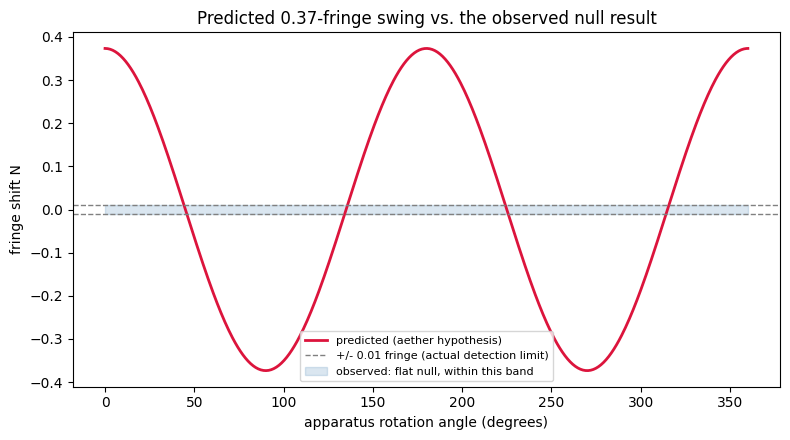

In [7]:
theta = np.linspace(0, 2*np.pi, 500)
# generalizing predicted_fringe_shift to an arbitrary rotation angle:
# the effective aether-wind projection onto each arm varies as cos(theta)/sin(theta),
# giving a fringe-shift signal proportional to cos(2*theta) (period pi, matching
# the historical apparatus's expected signature)
N_vs_theta = N_predicted * np.cos(2*theta)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(np.degrees(theta), N_vs_theta, color='crimson', lw=2, label='predicted (aether hypothesis)')
ax.axhline(0.01, color='gray', ls='--', lw=1, label='+/- 0.01 fringe (actual detection limit)')
ax.axhline(-0.01, color='gray', ls='--', lw=1)
ax.fill_between(np.degrees(theta), -0.01, 0.01, color='steelblue', alpha=0.2, label='observed: flat null, within this band')
ax.set_xlabel('apparatus rotation angle (degrees)'); ax.set_ylabel('fringe shift N')
ax.set_title(f'Predicted {N_predicted:.2f}-fringe swing vs. the observed null result')
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig('michelson_fringe_vs_angle.png', dpi=100, bbox_inches='tight')
plt.show()


## 4. Sensitivity: How Much Bigger Would L or v Need to Be?


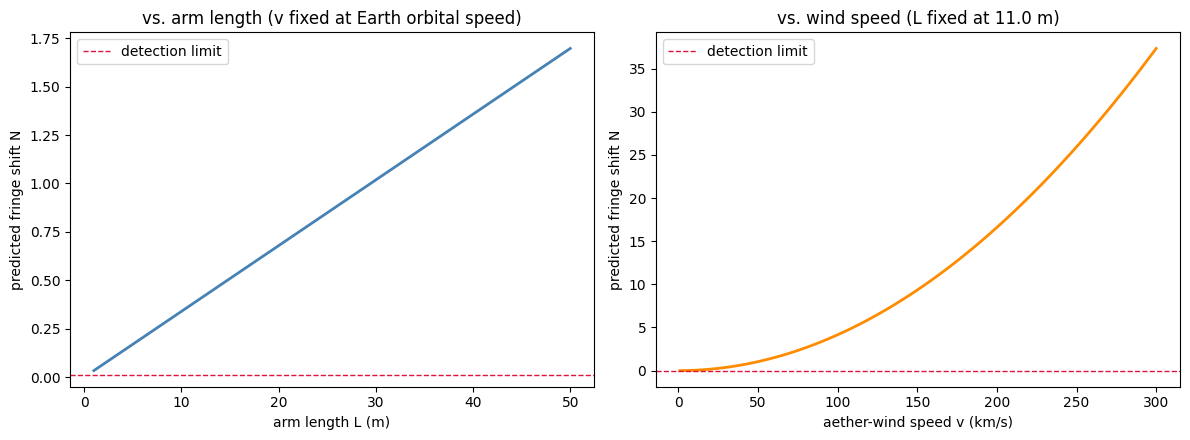

Since N scales as v^2/wavelength * L, Michelson-Morley was already sensitive
enough to detect the FULL 30 km/s orbital speed -- the null result is not a
sensitivity limitation, it is direct evidence there is no aether wind at all.


In [8]:
L_sweep = np.linspace(1, 50, 100)
N_vs_L = [mm.predicted_fringe_shift(Lv, v_earth, wavelength) for Lv in L_sweep]

v_sweep = np.linspace(1e3, 3e5, 100)
N_vs_v = [mm.predicted_fringe_shift(L, vv, wavelength) for vv in v_sweep]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(L_sweep, N_vs_L, color='steelblue', lw=2)
axes[0].axhline(0.01, color='crimson', ls='--', lw=1, label='detection limit')
axes[0].set_xlabel('arm length L (m)'); axes[0].set_ylabel('predicted fringe shift N')
axes[0].set_title(f'vs. arm length (v fixed at Earth orbital speed)')
axes[0].legend()

axes[1].plot(v_sweep/1e3, N_vs_v, color='darkorange', lw=2)
axes[1].axhline(0.01, color='crimson', ls='--', lw=1, label='detection limit')
axes[1].set_xlabel('aether-wind speed v (km/s)'); axes[1].set_ylabel('predicted fringe shift N')
axes[1].set_title(f'vs. wind speed (L fixed at {L} m)')
axes[1].legend()
plt.tight_layout()
plt.savefig('michelson_sensitivity_sweep.png', dpi=100, bbox_inches='tight')
plt.show()

print('Since N scales as v^2/wavelength * L, Michelson-Morley was already sensitive')
print('enough to detect the FULL 30 km/s orbital speed -- the null result is not a')
print('sensitivity limitation, it is direct evidence there is no aether wind at all.')


## 5. Why Special Relativity Predicts an EXACT Null, Not Just a Small One

The aether-wind calculation above assumes a preferred rest frame (the
aether) that light's speed is measured relative to, with the apparatus
moving through it. Special relativity denies that assumption entirely:
light travels at $c$ in EVERY inertial frame, including the apparatus's
own rest frame. In the apparatus's frame there is no wind to correct for
at all -- both arms see light travel at $c$, round trip time is
$2L/c$ for EITHER arm, and $\Delta t=0$ identically, not
approximately. `dgs/special_relativity.py` develops this resolution in
full; the point here is narrower: the aether calculation above is a
COMPETING hypothesis, cleanly falsified by comparing its specific
numerical prediction (section 2) against the specific observed limit.


## 6. What It Actually Takes to Build One: Mirror Machining and Optical Sourcing

Everything above assumes IDEAL mirrors and a perfect 50/50 beamsplitter.
Building a real interferometer sensitive enough to matter means:

- **Surface flatness**: interferometer mirrors need $\lambda/10$ to
  $\lambda/20$ flatness -- for 590 nm sodium light, that's **30-60 nm**
  peak-to-valley across the whole optical surface. For comparison, a
  typical machined metal part is flat to maybe 10-25 **micrometers** (a
  400-800x LOOSER tolerance) -- ordinary machining cannot get anywhere
  close; this is why interferometer optics are ground and POLISHED
  (pitch-lap polishing against a reference flat), not milled.
- **The verification problem is recursive**: the standard way to CHECK
  whether a mirror is flat enough is itself an interferometric test
  (a Fizeau or Twyman-Green interferometer comparing the mirror under
  test against a known-flat reference) -- you need interferometry to
  verify optics good enough to build an interferometer.
- **"LensCrafters" is the wrong source, categorically**: consumer
  eyeglass lens fabrication targets DIOPTER accuracy (optical power, a
  focal-length spec measured in fractions of a diopter) and cosmetic
  surface quality, not nanometer-scale flatness -- a completely different
  tolerance regime serving a completely different purpose (correcting
  vision, not preserving wavefront coherence). Precision optical flats
  and mirrors for interferometry come from optical fabrication houses
  (e.g. Thorlabs, Edmund Optics, or a custom optics shop) that spec and
  test flatness directly, not prescription labs.
- **The beamsplitter** needs a precisely 50/50 (or otherwise well-
  characterized) dielectric coating on an equally flat substrate --
  another optical-coating-house product, not a machined or molded part.
- **Realistic bench-scale cost/sourcing**: a basic educational Michelson
  interferometer kit (smaller arms, visible-light laser source instead of
  sodium lamp, adequate but not research-grade flatness) is a standard
  catalog item from the same optics suppliers above -- far more practical
  than sourcing/fabricating research-grade optics from scratch for a demo.


## 7. Electronic Readout: the Technology This Experiment Actually Needs

Section 6 covered the OPTICS well enough to form a fringe pattern.
Reading that pattern out as a number (not squinting at fringes by eye)
needs a photodiode and a transimpedance amplifier -- the exact circuit
`dgs/photodetector_tia_frontend.py` builds and verifies. As the apparatus
rotates, the interference intensity at the detector is
$$I(\theta)=\frac{I_0}{2}\Big(1+\cos\big(2\pi N(\theta)\big)\Big),
\qquad N(\theta)=N_{predicted}\cos(2\theta)$$
(section 3's fringe count, now converted to an actual intensity via the
standard two-beam interference formula). That intensity drives a real
photodiode + TIA chain end to end below -- with an explicit bandwidth
check confirming the TIA is nowhere near the bottleneck for a slowly
rotating apparatus.


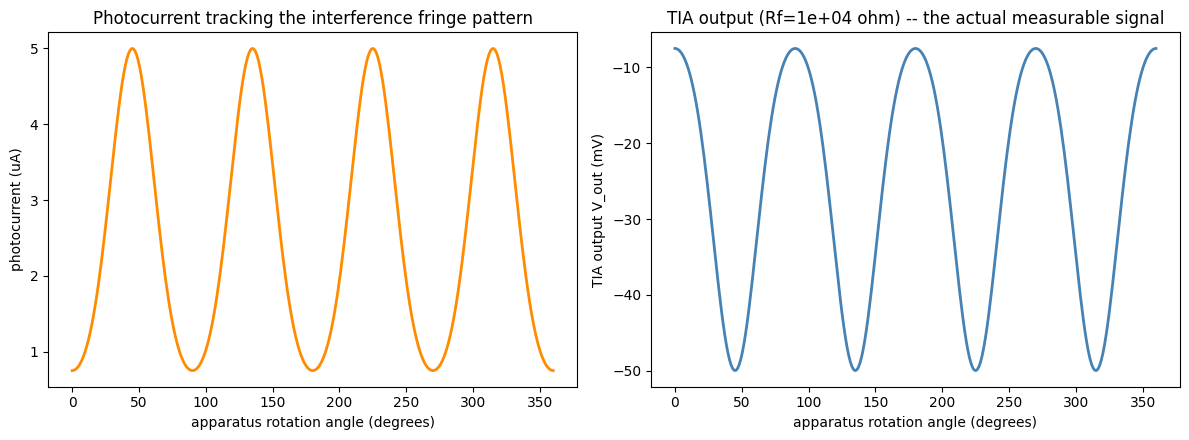

photocurrent range: 0.75 to 5.00 uA
TIA output range:   -50.00 to -7.50 mV


In [9]:
I0_W = 10e-6           # 10 uW optical power reaching the detector
responsivity = 0.5      # A/W, silicon photodiode at visible wavelengths
Rf_readout, Cf_readout = 1e4, 0.5e-12   # same TIA design as dgs/photodetector_tia_frontend.py

theta_readout = np.linspace(0, 2*np.pi, 300)
N_theta_readout = N_predicted*np.cos(2*theta_readout)
I_frac = 0.5*(1 + np.cos(2*np.pi*N_theta_readout))        # normalized interference intensity
I_ph_readout = responsivity * I0_W * I_frac                # photocurrent (A)
Vout_readout = np.array([tia.tia_transimpedance_gain_dc(Rf_readout) * i for i in I_ph_readout])  # quasi-static TIA output (V)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(np.degrees(theta_readout), I_ph_readout*1e6, color='darkorange', lw=2)
axes[0].set_xlabel('apparatus rotation angle (degrees)'); axes[0].set_ylabel('photocurrent (uA)')
axes[0].set_title('Photocurrent tracking the interference fringe pattern')

axes[1].plot(np.degrees(theta_readout), Vout_readout*1e3, color='steelblue', lw=2)
axes[1].set_xlabel('apparatus rotation angle (degrees)'); axes[1].set_ylabel('TIA output V_out (mV)')
axes[1].set_title(f'TIA output (Rf={Rf_readout:.0e} ohm) -- the actual measurable signal')
plt.tight_layout()
plt.savefig('michelson_tia_readout.png', dpi=100, bbox_inches='tight')
plt.show()

print(f'photocurrent range: {I_ph_readout.min()*1e6:.2f} to {I_ph_readout.max()*1e6:.2f} uA')
print(f'TIA output range:   {Vout_readout.min()*1e3:.2f} to {Vout_readout.max()*1e3:.2f} mV')


In [10]:
# bandwidth check: is the TIA fast enough for a rotating apparatus?
f_p_readout = tia.tia_bandwidth_hz(Rf_readout, Cf_readout)
rotation_period_s = 60.0   # a slow, hand-cranked rotation -- 1 revolution per minute
rotation_freq_hz = 1.0 / rotation_period_s

print(f'TIA -3dB bandwidth:        {f_p_readout/1e9:.3f} GHz')
print(f'apparatus rotation freq:   {rotation_freq_hz:.4f} Hz')
print(f'headroom: TIA bandwidth is {f_p_readout/rotation_freq_hz:.2e} times faster than the signal')
print('-> the TIA is nowhere near the bottleneck; a slowly rotating apparatus is quasi-static to it')


TIA -3dB bandwidth:        0.032 GHz
apparatus rotation freq:   0.0167 Hz
headroom: TIA bandwidth is 1.91e+09 times faster than the signal
-> the TIA is nowhere near the bottleneck; a slowly rotating apparatus is quasi-static to it


## 8. Engineering Interpretation

- Section 4's sensitivity sweep is the actual reason the null result is
  historically significant: Michelson-Morley wasn't underpowered (a bigger
  L or more sensitive detection would have helped a MARGINAL result) --
  the predicted signal was already comfortably above the detection floor,
  so its total absence is real evidence, not an inconclusive non-result.
- Section 6's recursive verification point (you need an interferometer to
  verify interferometer-grade optics) is a genuine metrology bootstrap
  problem, not a rhetorical flourish -- the SAME kind of "how do you
  verify the verifier" question `dgs/em_lagrangian_action.py`'s negative
  Bianchi-identity test and this repo's other verification-of-verification
  checks ask, here applied to a physical measurement instrument instead of
  a piece of code.
- The flatness-vs-machining-tolerance comparison (30-60 nm vs. 10-25 um)
  is a ~500x gap -- useful intuition for why "just machine it precisely"
  fails for optics in a way it doesn't for most mechanical parts.
- Section 7's TIA readout closes the loop this notebook opened by asking
  "how would you actually MEASURE this": the historical apparatus used a
  human eye counting fringes visually, but the identical electronics
  `dgs/photodetector_tia_frontend.py` verifies (KCL loop -> voltage) turns
  the same optics into a digitizable signal, with an explicit (not
  assumed) confirmation that a GHz-bandwidth TIA is absurdly overkill for
  a mechanically-rotated apparatus -- the bottleneck was always the optics
  and the human observer, never the electronics.


## 9. Research Discussion

- Could `predicted_fringe_shift` be extended to account for a REALISTIC
  mirror flatness error (adding a random wavefront distortion term) and
  show how much aether-wind signal would be masked by imperfect optics at
  various flatness specs -- connecting section 2's clean prediction to
  section 6's fabrication limits quantitatively?
- Modern equivalents (e.g. laser-ring gyroscopes, or LIGO's interferometry)
  push flatness/stability requirements FAR beyond section 6's numbers --
  would tracing the historical Michelson-Morley tolerance chain forward to
  LIGO's actual mirror specs make a compelling "how far metrology has
  come" follow-up?
- Section 5 stated relativity's resolution narratively. Could
  `dgs/special_relativity.py`'s length-contraction and time-dilation
  functions be used HERE to show algebraically that they exactly cancel
  the aether-frame calculation's predicted difference, rather than just
  asserting $\Delta t=0$ in the apparatus frame?


## 10. Possible Experiments

1. Build (or source, per section 6) a basic educational Michelson
   interferometer, measure your OWN fringe pattern, and compare against
   `predicted_fringe_shift` for your actual arm lengths and light source.
2. Deliberately introduce a small, known path-length change (e.g. a
   piezo-actuated mirror mount) and verify the OBSERVED fringe shift
   matches the module's prediction for that specific displacement --
   turning the null-result apparatus into a working displacement sensor.
3. Extend section 4's sensitivity sweep to find the MINIMUM arm length
   that would have kept the predicted shift comfortably above 0.01
   fringes even with a slower Earth (e.g., testing the experiment's
   robustness to a hypothetically smaller orbital speed).


## 11. Future Improvements

- `predicted_fringe_shift` uses the small-v/c approximation
  ($N\propto v^2/c^2$); section 1's EXACT `time_difference` could replace
  it directly for a relativistic-speed apparatus (not physically relevant
  for Earth's orbital speed, but a cleaner "no approximation" version).
- Section 3's rotation-angle formula ($\cos(2\theta)$) was stated by
  physical reasoning about the period, not derived from
  `time_difference` at an arbitrary arm orientation -- a full derivation
  generalizing `longitudinal_time`/`transverse_time` to an arm at angle
  $\theta$ to the wind (not just 0 or 90 degrees) would close that gap.
